In [1]:
import os
import copy
import numpy as np
import pandas
import matplotlib.pyplot as plt
from IPython.display import Image
import sklearn
from sklearn import model_selection
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer

# Handling missing values in a simple case

The goal of this tutorial is to evaluate and compare imputation methods in a simple case.

**Question 1**

The following function generates a dataset. What is the relation between the target variable `y` and the features given in `X`?

Sample a dataset of size 1000 and plot it on a 2D scatter plot:
* points $X_i$ are located at `(X[i, 0], X[i, 1])`;
* each point $X_i$ has a color depending of its label $y_i$ (one can use the argument `c` of the function `plt.scatter` and the function `plt.colorbar`).

In [2]:
def generate_without_missing_values(n_samples, rng=1):
    mean = [0, 0]
    cov = [[1, 0.9], [0.9, 1]]
    if not isinstance(rng, np.random.RandomState):
        rng = np.random.RandomState(rng)
    X = rng.multivariate_normal(mean, cov, size=n_samples)

    epsilon = 0.1 * rng.randn(n_samples)
    y = X[:, 0] + epsilon

    return X, y

**Answer**

`y` is equal to the first feature (plus noise).

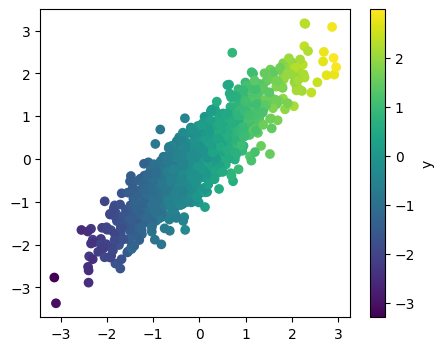

In [3]:
plt.rcParams['figure.figsize'] = (5, 4) # Smaller default figure size

plt.figure()
X_full, y_full = generate_without_missing_values(1000)
plt.scatter(X_full[:, 0], X_full[:, 1], c=y_full)
plt.colorbar(label='y')

## MCAR setting

**Question 2**

Use the following function to generate a MCAR dataset. 

Plot the result of data imputation with:
1. mean imputation;
2. MICE imputation.
Which imputation technique most resembles to the inital dataset?

One can use the `SimpleImputer` and `IterativeImputer` classes.

In [4]:
def generate_mcar(n_samples, missing_rate=.5, rng=42):
    X, y = generate_without_missing_values(n_samples, rng=rng)
    if not isinstance(rng, np.random.RandomState):
        rng = np.random.RandomState(rng)

    M = rng.binomial(1, missing_rate, (n_samples, 2))
    np.putmask(X, M, np.nan)

    return X, y

In [5]:
X, y = generate_mcar(500)

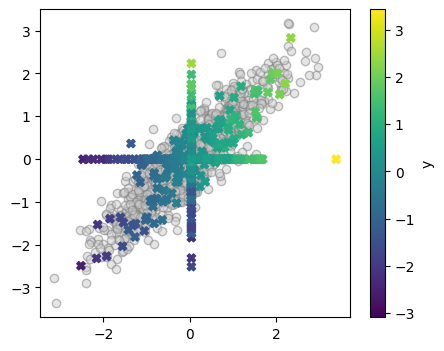

In [6]:
mean_imputer = SimpleImputer()

X_imputed = mean_imputer.fit_transform(X)

plt.figure()
plt.scatter(X_full[:, 0], X_full[:, 1], color='.8', ec='.5',
            label='All data', alpha=.5)
plt.scatter(X_imputed[:, 0], X_imputed[:, 1], c=y, marker='X',
            label='Imputed')
plt.colorbar(label='y')

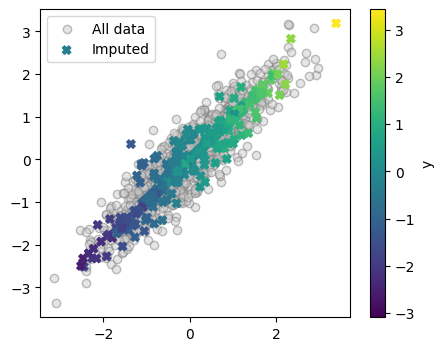

In [7]:
iterative_imputer = IterativeImputer()

iterative_imputer.fit(X)

X_imputed = iterative_imputer.transform(X)

plt.figure()
plt.scatter(X_full[:, 0], X_full[:, 1], color='.8', ec='.5',
            label='All data', alpha=.5)
plt.scatter(X_imputed[:, 0], X_imputed[:, 1], c=y, marker='X',
            label='Imputed')
plt.colorbar(label='y')
plt.legend()

## Supervised learning: imputation and a linear model

**Question 3**

For each imputation method, build a pipeline made of:
1. the chosen imputer;
2. a ridge regressor with integrated cross-validation.

Compute the cross-validation scores (with 10 folds) in each case and plot a boxplot of the scores to compare the imputation methods.

In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV

In [9]:
iterative_and_ridge = make_pipeline(IterativeImputer(), RidgeCV())

scores_iterative_and_ridge = model_selection.cross_val_score(
    iterative_and_ridge, X, y, cv=10)

In [10]:
mean_and_ridge = make_pipeline(SimpleImputer(), RidgeCV())

scores_mean_and_ridge = model_selection.cross_val_score(
    mean_and_ridge, X, y, cv=10)

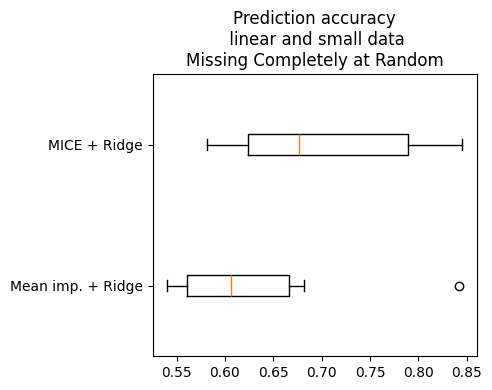

In [11]:
scores = pandas.DataFrame({'Mean imp. + Ridge': scores_mean_and_ridge,
             'MICE + Ridge': scores_iterative_and_ridge,
    })

plt.boxplot(scores, orientation='horizontal', tick_labels = scores.columns)
plt.title('Prediction accuracy\n linear and small data\n'
          'Missing Completely at Random')
plt.tight_layout()

**Question 4**

Now, perform the same set of experiments with a dataset of size 20000. What do we observe?

In [12]:
X, y = generate_mcar(n_samples=20000)

In [13]:
scores_iterative_and_ridge= model_selection.cross_val_score(
    iterative_and_ridge, X, y, cv=10)
scores_mean_and_ridge = model_selection.cross_val_score(
    mean_and_ridge, X, y, cv=10)

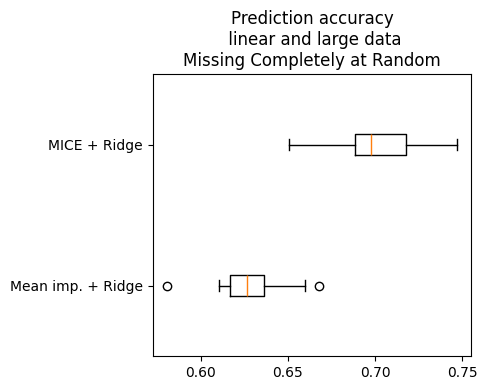

In [14]:
scores = pandas.DataFrame({'Mean imp. + Ridge': scores_mean_and_ridge,
             'MICE + Ridge': scores_iterative_and_ridge,
    })

plt.boxplot(scores, orientation='horizontal', tick_labels = scores.columns)
plt.title('Prediction accuracy\n linear and large data\n'
          'Missing Completely at Random')
plt.tight_layout()

**Answer**

The results are even more in favor of MICE.

## MNAR setting: censored data

In [15]:
def generate_censored(n_samples, missing_rate=.4, rng=42):
    X, y = generate_without_missing_values(n_samples, rng=rng)
    if not isinstance(rng, np.random.RandomState):
        rng = np.random.RandomState(rng)

    B = rng.binomial(1, 2 * missing_rate, (n_samples, 2))
    M = (X > 0.5) * B

    np.putmask(X, M, np.nan)

    return X, y

**Question 5**

Generate a dataset of size 500 according to the MNAR setting.

Compare the imputation techniques, and compare them with a model that handles natively missing data (decision trees, random forests...). 

What do we observe?

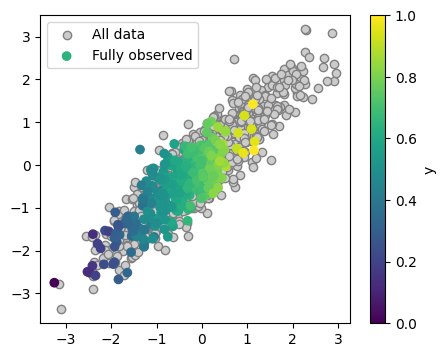

In [16]:
X, y = generate_censored(500, missing_rate=.4)

plt.figure()
plt.scatter(X_full[:, 0], X_full[:, 1], color='.8', ec='.5',
            label='All data')
plt.colorbar(label='y')
plt.scatter(X[:, 0], X[:, 1], c=y, label='Fully observed')
plt.legend()

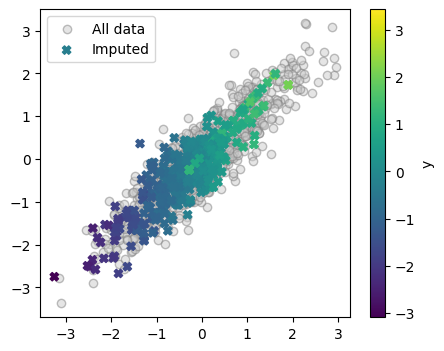

In [17]:
iterative_imputer = IterativeImputer()
X_imputed = iterative_imputer.fit_transform(X)

plt.figure()
plt.scatter(X_full[:, 0], X_full[:, 1], color='.8', ec='.5',
            label='All data', alpha=.5)
plt.scatter(X_imputed[:, 0], X_imputed[:, 1], c=y, marker='X',
            label='Imputed')
plt.colorbar(label='y')
plt.legend()

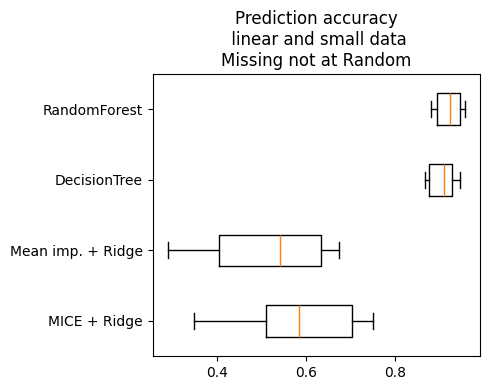

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

scores = dict()

# Iterative imputation and linear model
scores['MICE + Ridge'] = model_selection.cross_val_score(
    iterative_and_ridge, X, y, cv=10)

# Mean imputation and linear model
scores['Mean imp. + Ridge'] = model_selection.cross_val_score(
    mean_and_ridge, X, y, cv=10)

"""
# IterativeImputer and non-linear model
iterative_and_gb = make_pipeline(IterativeImputer(),
                            HistGradientBoostingRegressor())
scores['Mean imputation\n+ HistGradientBoostingRegressor'] = model_selection.cross_val_score(
    iterative_and_gb, X, y, cv=10)
"""

# And now the RandomForestRegressor, whithout imputation
scores['DecisionTree'] = model_selection.cross_val_score(
    DecisionTreeRegressor(), X, y, cv=10)

# And now the RandomForestRegressor, whithout imputation
scores['RandomForest'] = model_selection.cross_val_score(
    RandomForestRegressor(), X, y, cv=10)

df = pandas.DataFrame(scores)

# We plot the results
plt.boxplot(df, orientation='horizontal', tick_labels = df.columns)
plt.title('Prediction accuracy\n linear and small data\n'
          'Missing not at Random')
plt.tight_layout()

**Answer**

Tree-based models that handle natively missing values perform much better than small models combined with imputation techniques.

BSD 2-Clause License

Copyright (c) 2021, dirty-data-science
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:

1. Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

2. Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS"
AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE
IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE ARE
DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT HOLDER OR CONTRIBUTORS BE LIABLE
FOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR CONSEQUENTIAL
DAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF SUBSTITUTE GOODS OR
SERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS INTERRUPTION) HOWEVER
CAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN CONTRACT, STRICT LIABILITY,
OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE) ARISING IN ANY WAY OUT OF THE USE
OF THIS SOFTWARE, EVEN IF ADVISED OF THE POSSIBILITY OF SUCH DAMAGE.